# Milestone 2 - Task 7: Correlation Analysis and EDA Summary

This analysis examines relationships between numerical campaign features and campaign success, then summarizes the key findings from the Milestone 2 exploratory data analysis to help guide feature selection for machine learning.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/kickstarter_us_filtered.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (38504, 17)


,project id,name,url,category,subcategory,location,status,goal,pledged,funded percentage,backers,funded date,levels,reward levels,updates,comments,duration
0,39409,WHILE THE TREES SLEEP,http://www.kickstarter.com/projects/emiliesaba...,Film & Video,Short Film,"Columbia, MO",successful,10500.0,11545.0,1.099524,66,"Fri, 19 Aug 2011 19:28:17 -0000",7,"$25,$50,$100,$250,$500,$1,000,$2,500",10,2,30.00
1,126581,Educational Online Trading Card Game,http://www.kickstarter.com/projects/972789543/...,Games,Board & Card Games,"Maplewood, NJ",failed,4000.0,20.0,0.005000,2,"Mon, 02 Aug 2010 03:59:00 -0000",5,"$1,$5,$10,$25,$50",6,0,47.18
2,237090,GETTING OVER - One son's search to finally kno...,http://www.kickstarter.com/projects/charnick/g...,Film & Video,Documentary,"Los Angeles, CA",successful,6000.0,6535.0,1.089167,100,"Sun, 08 Apr 2012 02:14:00 -0000",13,"$1,$10,$25,$30,$50,$75,$85,$100,$110,$250,$500...",4,0,32.22
3,246101,The Launch of FlyeGrlRoyalty &quot;The New Nam...,http://www.kickstarter.com/projects/flyegrlroy...,Fashion,Fashion,"Novi, MI",failed,3500.0,0.0,0.000000,0,"Wed, 01 Jun 2011 15:25:39 -0000",6,"$10,$25,$50,$100,$150,$250",2,0,30.00
4,316217,Dinner Party - a short film about friendship.....,http://www.kickstarter.com/projects/249354515/...,Film & Video,Short Film,"Portland, OR",successful,3500.0,3582.0,1.023331,39,"Wed, 22 Jun 2011 13:33:00 -0000",7,"$5,$25,$50,$100,$250,$500,$1,000",8,0,21.43


## Correlation Analysis

To examine the relationship between numerical campaign features and campaign success, campaign status is converted into a binary variable where successful campaigns are represented as 1 and failed campaigns as 0.

In [4]:
df["success"] = (df["status"] == "successful").astype(int)

print(df["success"].value_counts())
print("\nSuccess rate:", round(df["success"].mean() * 100, 2), "%")

success
1    21075
0    17429
Name: count, dtype: int64

Success rate: 54.73 %


### Numerical Features

The numerical campaign features are selected to examine their correlations with one another and with campaign success.

In [5]:
numeric_features = [
    "goal",
    "pledged",
    "funded percentage",
    "backers",
    "levels",
    "updates",
    "comments",
    "duration",
    "success"
]

correlation_df = df[numeric_features]

correlation_df.head()

,goal,pledged,funded percentage,backers,levels,updates,comments,duration,success
0,10500.0,11545.0,1.099524,66,7,10,2,30.00,1
1,4000.0,20.0,0.005000,2,5,6,0,47.18,0
2,6000.0,6535.0,1.089167,100,13,4,0,32.22,1
3,3500.0,0.0,0.000000,0,6,2,0,30.00,0
4,3500.0,3582.0,1.023331,39,7,8,0,21.43,1


In [6]:
# Calculate the correlation matrix
correlation_matrix = correlation_df.corr()

# Show each feature's correlation with campaign success
success_correlations = correlation_matrix["success"].sort_values(
    ascending=False
)

success_correlations

success              1.000000
updates              0.390119
levels               0.146061
backers              0.072557
pledged              0.063110
comments             0.037834
funded percentage    0.018648
goal                -0.035982
duration            -0.142657
Name: success, dtype: float64

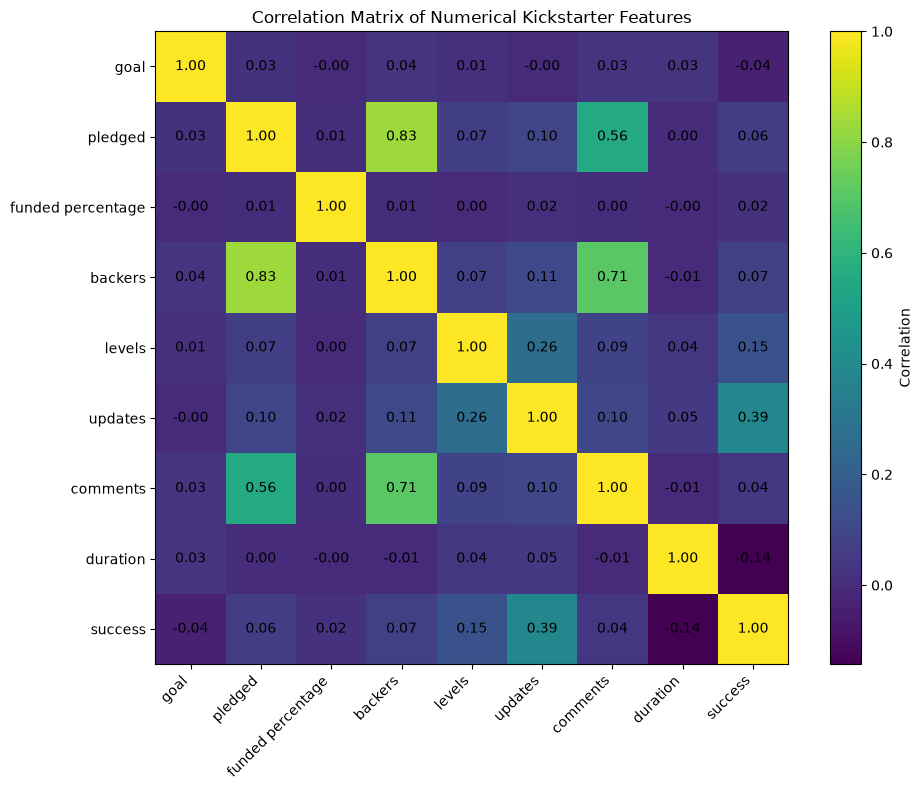

In [7]:
# Visualize correlations between numerical campaign features
fig, ax = plt.subplots(figsize=(10, 8))

heatmap = ax.imshow(correlation_matrix)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_matrix.columns)

# Display correlation values inside each cell
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix of Numerical Kickstarter Features")
plt.colorbar(heatmap, label="Correlation")
plt.tight_layout()
plt.show()

### Correlation Findings

- Among the numerical features examined, `updates` had the strongest positive correlation with campaign success (r = 0.39).
- The number of reward tiers (`levels`) had a weak positive correlation with success (r = 0.15), while campaign `duration` had a weak negative correlation (r = -0.14).
- `goal`, `pledged`, `backers`, `comments`, and `funded percentage` showed relatively weak linear correlations with campaign success.
- Several campaign activity variables were strongly related to one another. In particular, `pledged` and `backers` had a strong positive correlation (r = 0.83), while `backers` and `comments` were also strongly correlated (r = 0.71).
- These correlations describe associations in the dataset and do not imply causation. In addition, some variables such as `pledged`, `backers`, `updates`, `comments`, and `funded percentage` may contain information collected after a campaign launches, so their suitability for an at-launch prediction model should be evaluated carefully.

## Summary of Milestone 2 EDA Findings

The exploratory analyses from Tasks 1–6 identified several relationships between campaign characteristics and campaign success.

### Task 1: Goal Amount vs. Success
Campaigns with lower funding goals generally had higher observed success rates. Successful campaigns had a median goal of USD 3,000, compared with USD 5,000 for failed campaigns. Success rates declined as funding goals increased, suggesting that goal amount may be an important feature to evaluate during modeling.

### Task 2: Campaign Duration vs. Success
Campaigns lasting up to 45 days had similar observed success rates of about 58%, while longer campaigns had lower success rates. Campaigns lasting 45–60 days had an observed success rate of about 47%, and campaigns longer than 60 days had a rate of about 43%. This suggests that longer campaign duration is associated with lower success.

### Task 3: Campaign Engagement vs. Success
The engagement analysis showed that campaign activity variables such as updates and comments were associated with campaign outcomes. The correlation analysis also showed that updates had the strongest positive linear correlation with success among the numerical features examined. However, these engagement variables may reflect activity that occurs after a campaign launches and should therefore be evaluated for potential data leakage before modeling.

### Task 4: Category and Subcategory vs. Success
Success rates differed across campaign categories and subcategories. Dance, Theater, and Music had some of the highest observed category-level success rates, while Fashion and Technology had lower rates. Differences were also observed among subcategories, indicating that campaign type may provide useful information for predicting success.

### Task 5: Location vs. Success
Success rates varied across states and campaign locations. Among states with at least 100 campaigns, Vermont and Rhode Island had some of the highest observed success rates. At the location level, Brooklyn, NY had the highest observed success rate among locations with at least 300 campaigns, at approximately 72.5%. These differences suggest that location may be worth evaluating as a predictive feature.

### Task 6: Reward Levels vs. Success
Campaigns with more reward tiers generally had higher observed success rates. Success increased from approximately 31.5% for campaigns with 0–2 reward tiers to 64.1% for campaigns with 11–20 tiers and 74.4% for campaigns with 21 or more tiers. Reward levels also had a weak positive correlation with success (r = 0.15). Because campaigns with very high numbers of reward tiers were relatively rare, these results should be interpreted carefully.

Overall, these findings describe associations in the dataset rather than causal relationships. Several campaign characteristics appear potentially useful for modeling, but their predictive value should be evaluated together rather than independently.

## Implications for Feature Selection

The EDA results suggest that several campaign characteristics may be useful features for predicting campaign success. Goal amount, campaign duration, category, subcategory, location, and number of reward levels are all available campaign characteristics that showed differences in success outcomes and should be considered during modeling.

Correlation alone should not determine whether a feature is useful. For example, goal amount had a very weak linear correlation with success, but the goal analysis showed that success rates decreased substantially across higher goal ranges. Similarly, categorical features such as category and location are not represented in the numerical correlation matrix but showed meaningful differences in observed success rates.

Some numerical variables require additional caution. `pledged`, `funded percentage`, `backers`, `updates`, and `comments` may contain information generated after a campaign launches. Since the project aims to predict campaign success at or near launch, these variables should be reviewed for potential data leakage before being included in the final model.

For the modeling stage, the team should prioritize launch-time features and evaluate their predictive value together using appropriate classification models and validation metrics.